In [1]:
import time
from pathlib import Path
from matplotlib import pyplot as plt

import numpy as np

import sympy

from jwst import datamodels

from astropy import units as u
from astropy.coordinates import SkyCoord, SpectralCoord

import jax
from jax import numpy as jnp
import equinox as eqx
import optax

from tqdm.auto import tqdm

jax.devices()

[CudaDevice(id=0)]

In [ ]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))
n6791dms = [datamodels.open(fn) for fn in n6791fits]

dm0 = n6791dms[0]
dm0.info()

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 5.0.0
├─history (dict)
│ └─extensions (list) ...
├─_fits_hash (str): 0eb414a289c275d021142f61dde4a617b19d389e28f6ae3c1799b9cd500086a8
├─cal_logs (dict)
│ ├─calwebb_detector1 (list) ...
│ └─calwebb_spec2 (list) ...
├─meta (dict)
│ ├─aperture (dict) ...
│ ├─asn (dict) ...
│ ├─cal_step (dict) ...
│ ├─calibration_software_revision (str): RELEASE
│ ├─calibration_software_version (str): 1.20.2
│ ├─compress (bool): False
│ ├─data_processing_software_version (str): 2025_4a
│ ├─date (str): 2025-12-23T01:58:56.828
│ └─26 not shown
└─slits (list) ...
Some nodes not shown.


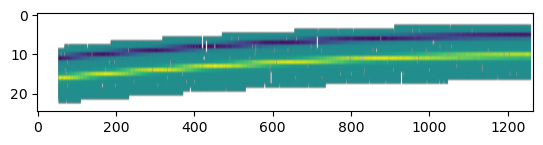

In [3]:
s = dm0.slits[42]
plt.imshow(s.data, aspect=10)

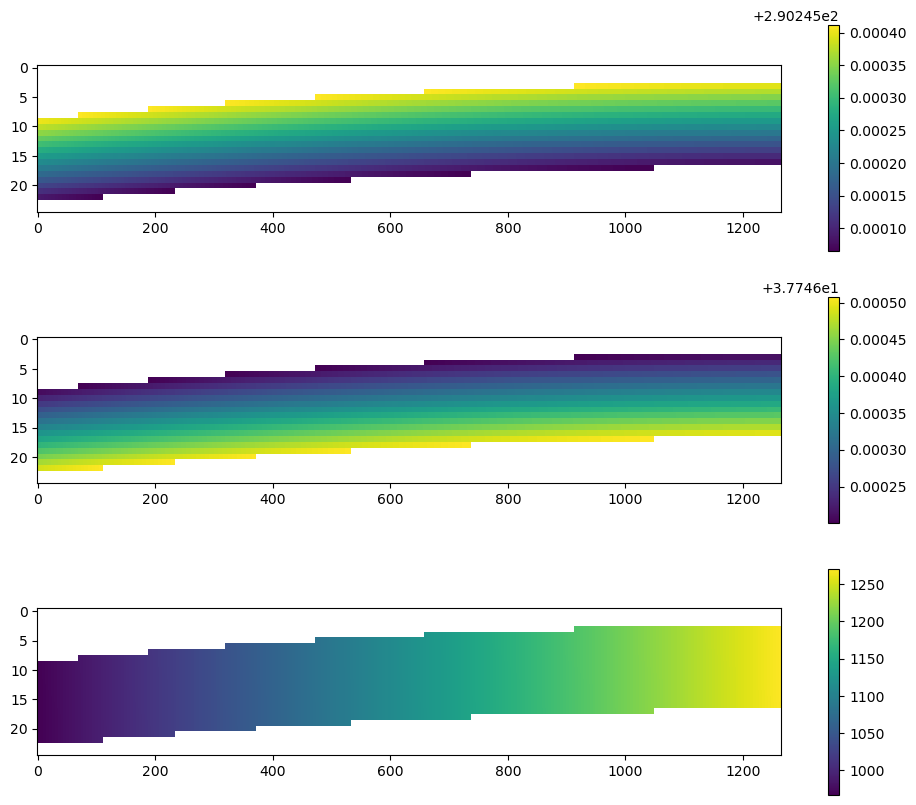

In [4]:
yg, xg = np.indices(s.data.shape)

sky,spec = s.meta.wcs.pixel_to_world(xg, yg)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

sc = ax1.imshow(sky.ra.deg, aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax1)
sc = ax2.imshow(sky.dec.deg, aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax2)
sc = ax3.imshow(spec.to_value(u.nm), aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax3)

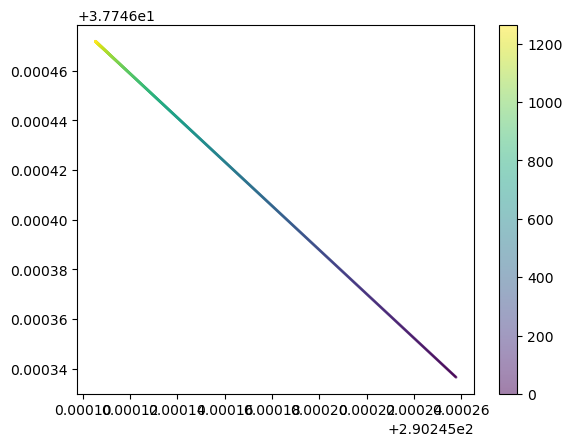

In [5]:
plt.scatter(sky.ra.deg[15], sky.dec.deg[15], c=xg[15], alpha=.5, s=1)
plt.colorbar();

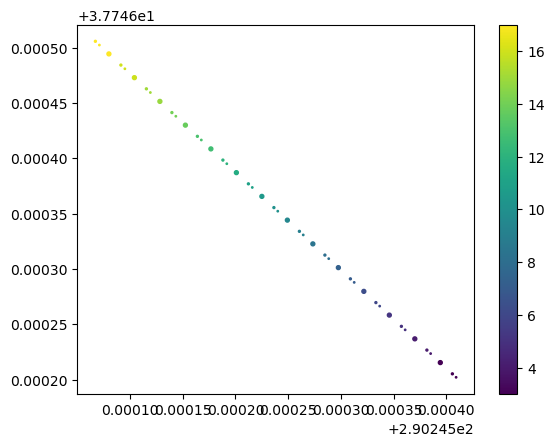

In [6]:
plt.scatter(sky.ra.deg[:, 600], sky.dec.deg[:, 600], c=yg[:, 600], alpha=1, s=8)
plt.scatter(sky.ra.deg[:, 200], sky.dec.deg[:, 200], c=yg[:, 200], alpha=1, s=1)
plt.scatter(sky.ra.deg[:, 1000], sky.dec.deg[:, 1000], c=yg[:, 1000], alpha=1, s=2)
plt.colorbar()

In [7]:
s.meta.pointing.pa_v3 + (138 - 90) - 180

47.65026967358739

Now experiment with the inverse case: mapping world to pixels.

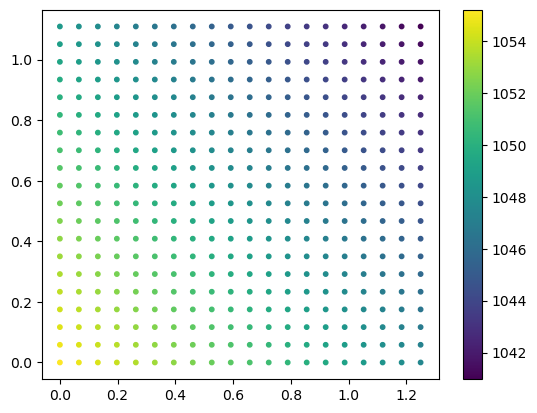

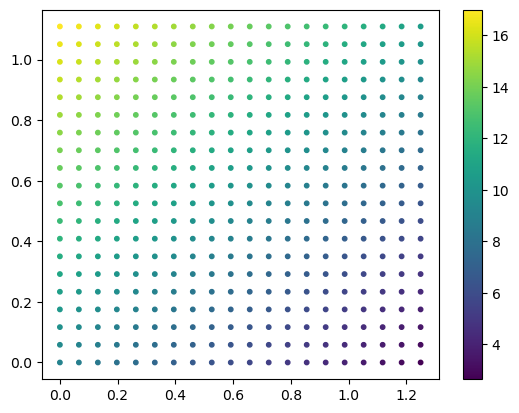

In [8]:
rarange = (np.nanmin(sky.ra).deg, np.nanmax(sky.ra).deg)
decrange = (np.nanmin(sky.dec).deg, np.nanmax(sky.dec).deg)
rag, decg = np.mgrid[rarange[0]:rarange[1]:20j, decrange[0]:decrange[1]:20j]*u.deg

specrange = (np.nanmin(spec).to_value(u.nm), np.nanmax(spec).to_value(u.nm))
specmid = np.mean(specrange)*u.nm

px, py = s.meta.wcs.world_to_pixel(SkyCoord(rag, decg), SpectralCoord(specmid + 100*u.nm))


plt.scatter((rag.ravel() - rag.min()).to(u.arcsec), (decg.ravel() - decg.min()).to(u.arcsec), c=px.ravel(), s=10)
plt.colorbar()

plt.figure()
plt.scatter((rag.ravel() - rag.min()).to(u.arcsec), (decg.ravel() - decg.min()).to(u.arcsec), c=py.ravel(), s=10)
plt.colorbar()

In [9]:
%timeit s.meta.wcs.pixel_to_world(xg, yg)
%timeit s.meta.wcs.world_to_pixel(sky, spec)

xg.shape

22.1 ms ± 235 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
62.4 ms ± 311 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


(25, 1266)

Should be able to go much faster than that.

# Try using equinox to solve the WCS problem

## first with a vanilla MLP

In [10]:
class PixelToWorldNetwork(eqx.Module):
    layers: list

    def __init__(self, key, innerneurons=128, n_layers=3):
        assert n_layers > 2, 'need at least an input and output layer'
        keys = jax.random.split(key, n_layers)
        self.layers = [eqx.nn.Linear(2, innerneurons, key=keys[0])]
        for i in range(n_layers-2):
            self.layers.append(eqx.nn.Linear(innerneurons, innerneurons, key=keys[i+1]))
        self.layers.append(eqx.nn.Linear(innerneurons, 3, key=keys[-1]))

    def __call__(self, x):
        for layer in self.layers:
            x = jax.nn.gelu(layer(x))
        return x

#@eqx.filter_value_and_grad
@eqx.filter_jit
def loss(model, x, y): #leastsq loss for regression
    pred = jax.vmap(model)(x) # batch the model over the input
    return jnp.mean((pred - y)**2)

loss_grad = eqx.filter_grad(loss)
    
model = PixelToWorldNetwork(jax.random.PRNGKey(42))
loss(model, jnp.array([[0.0, 0.0]]), jnp.array([[0.0, 0.0, 0.0]])), loss_grad(model, jnp.array([[0.0, 0.0]]), jnp.array([[0.0, 0.0, 0.0]]))

(Array(0.00033726, dtype=float32),
 PixelToWorldNetwork(
   layers=[
     Linear(
       weight=f32[128,2],
       bias=f32[128],
       in_features=2,
       out_features=128,
       use_bias=True
     ),
     Linear(
       weight=f32[128,128],
       bias=f32[128],
       in_features=128,
       out_features=128,
       use_bias=True
     ),
     Linear(
       weight=f32[3,128],
       bias=f32[3],
       in_features=128,
       out_features=3,
       use_bias=True
     )
   ]
 ))

In [11]:
rarng = (np.nanmin(sky.ra).deg, np.nanmax(sky.ra).deg)
decrng = (np.nanmin(sky.dec).deg, np.nanmax(sky.dec).deg)
specrng = (np.nanmin(spec).to_value(u.nm), np.nanmax(spec).to_value(u.nm))

  0%|          | 0/1500 [00:00<?, ?it/s]

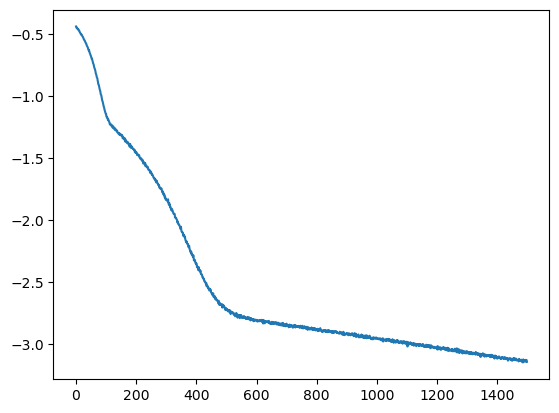

In [12]:
BATCH_SIZE = 4096
NITERS = 1500
LEARNING_RATE = 1e-4

MODEL_SEED = 42
DATA_SEED = MODEL_SEED + 1


model = PixelToWorldNetwork(jax.random.PRNGKey(MODEL_SEED))

optim = optax.adamw(LEARNING_RATE)

opt_state = optim.init(eqx.filter(model, eqx.is_array))

@eqx.filter_jit
def update(model, opt_state, x, y):
    loss_value, grads = eqx.filter_value_and_grad(loss)(model, x, y)
    updates, opt_state = optim.update(grads, opt_state, eqx.filter(model, eqx.is_array))

    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value


yscale = jnp.array([rarng[1] - rarng[0], decrng[1] - decrng[0], specrng[1] - specrng[0]])
yoff = jnp.array([rarng[0], decrng[0], specrng[0]])

skeys = jax.random.split(jax.random.PRNGKey(MODEL_SEED), NITERS)
losses = []
t = tqdm(range(NITERS))
for i in t:

    # make data
    key = skeys[i]
    U = jax.random.uniform(key, shape=(2*BATCH_SIZE, 2))
    Xy = U[:, 0]*s.data.shape[0]
    Xx = U[:, 1]*s.data.shape[1]
    
    worldsky, worldspec = s.meta.wcs.pixel_to_world(Xx, Xy)
    msk = np.isfinite(worldsky.ra.value) & np.isfinite(worldspec.value)

    Y = jnp.stack([worldsky.ra.deg[msk][:BATCH_SIZE],
                   worldsky.dec.deg[msk][:BATCH_SIZE],
                   worldspec.to_value(u.nm)[msk][:BATCH_SIZE]],
                   axis=-1)
    model, opt_state, train_loss = update(model, opt_state, U[msk][:BATCH_SIZE], (Y-yoff)/yscale)
    losses.append(train_loss)

    t.set_description(f'loss: {train_loss:.4f}')

plt.plot(np.log10(losses))



In [13]:
@eqx.filter_jit
def infer(model, x):

    Ux = x[...,0]/s.data.shape[0]
    Uy = x[...,1]/s.data.shape[1]

    pred = jax.vmap(model)(jnp.stack([Ux, Uy], axis=-1))
    return pred*yscale + yoff

# compile laxily
res = infer(model, jnp.array([[600], [10]]).T)

st = time.time()
res = infer(model, jnp.array([[600], [10]]).T)
res.block_until_ready()
et = time.time()

res, et-st

(Array([[ 290.24506 ,   37.754555, 1498.6919  ]], dtype=float32),
 0.0006570816040039062)

Still need to do some accuracy tests but it's the right ballpark?

Oh, but try with the baked-in MLP

  0%|          | 0/500 [00:00<?, ?it/s]

(<SkyCoord (ICRS): (ra, dec) in deg
     [(290.24527, 37.746323)]>,
 <SpectralCoord [1111.706] nm>)

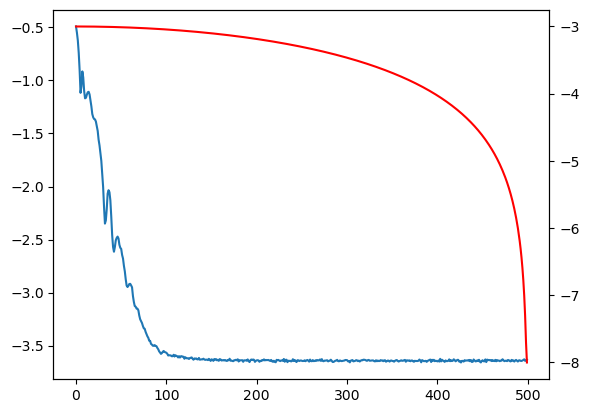

In [14]:
BATCH_SIZE = 4096
NITERS = 500
LEARNING_RATES = (1e-3, 1e-5)
EVALEVERY = 10

MODEL_SEED = 42
DATA_SEED = MODEL_SEED + 1

yscale = jnp.array([rarng[1] - rarng[0], decrng[1] - decrng[0], specrng[1] - specrng[0]])
yoff = jnp.array([rarng[0], decrng[0], specrng[0]])

model = eqx.nn.MLP(in_size=2, out_size=3, width_size=256, depth=4, activation=jax.nn.gelu, key=jax.random.PRNGKey(MODEL_SEED))

lrsched = optax.cosine_decay_schedule(LEARNING_RATES[0], NITERS, LEARNING_RATES[1])
optim = optax.adamw(lrsched)
opt_state = optim.init(eqx.filter(model, eqx.is_array))

@eqx.filter_jit
def update(model, opt_state, x, y):
    loss_value, grads = eqx.filter_value_and_grad(loss)(model, x, y)
    updates, opt_state = optim.update(grads, opt_state, eqx.filter(model, eqx.is_array))

    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

@eqx.filter_jit
def infer_pix_to_world_vals(model, x, y):
    Ux = x/s.data.shape[1]
    Uy = y/s.data.shape[0]

    pred = jax.vmap(model)(jnp.stack([Ux, Uy], axis=-1))
    return pred*yscale + yoff



def infer_pix_to_world(model, x, y):
    pred_world = infer_pix_to_world_vals(model, x, y)
    ra = pred_world[:, 0]*u.deg
    dec = pred_world[:, 1]*u.deg
    predsky = SkyCoord(ra=ra, dec=dec)
    predspec = SpectralCoord(pred_world[:, 2] << u.nm)

    return predsky, predspec

def evaluate(model, n):
    U = jax.random.uniform(key, shape=(2*n, 2))
    Xx = U[:, 0]*s.data.shape[1]
    Xy = U[:, 1]*s.data.shape[0]

    worldsky, worldspec = s.meta.wcs.pixel_to_world(Xx, Xy)
    msk = np.isfinite(worldsky.ra.value) & np.isfinite(worldspec.value)

    Y = jnp.stack([worldsky.ra.deg[msk][:n],
                   worldsky.dec.deg[msk][:n],
                   worldspec.to_value(u.nm)[msk][:n]],
                   axis=-1)

    pred_world = infer_pix_to_world_vals(model, Xx[msk][:n], Xy[msk][:n])
    ra = pred_world[:, 0]*u.deg
    dec = pred_world[:, 1]*u.deg
    predsky = SkyCoord(ra=ra, dec=dec)
    predspec = SpectralCoord(pred_world[:, 2] << u.nm)

    sep =  worldsky[msk][:n].separation(predsky)
    dspec = worldspec[msk][:n]-predspec

    return sep, dspec

skeys = jax.random.split(jax.random.PRNGKey(MODEL_SEED), NITERS)
losses = []
lrs = []
evals = []
t = tqdm(range(NITERS))
for i in t:

    # make data
    key = skeys[i]
    U = jax.random.uniform(key, shape=(2*BATCH_SIZE, 2))
    Xx = U[:, 0]*s.data.shape[1]
    Xy = U[:, 1]*s.data.shape[0]

    worldsky, worldspec = s.meta.wcs.pixel_to_world(Xx, Xy)
    msk = np.isfinite(worldsky.ra.value) & np.isfinite(worldspec.value)

    Y = jnp.stack([worldsky.ra.deg[msk][:BATCH_SIZE],
                   worldsky.dec.deg[msk][:BATCH_SIZE],
                   worldspec.to_value(u.nm)[msk][:BATCH_SIZE]],
                   axis=-1)
    model, opt_state, train_loss = update(model, opt_state, U[msk][:BATCH_SIZE], (Y-yoff)/yscale)
    losses.append(train_loss)
    lrs.append(lrsched(opt_state[0].count))

    if i % EVALEVERY == 0:
        sep, dspec = evaluate(model, 1000)
        evals.append((i, sep, dspec))


    t.set_description(f'loss: {train_loss:.4}, lr{lrs[-1]:.2e}')

plt.plot(np.log10(losses))
plt.twinx()
plt.plot(np.log10(lrs), color='r')

infer_pix_to_world(model, np.array([600]), np.array([10]))

(np.float64(0.00037220648303016625), np.float64(0.016356662122037426))

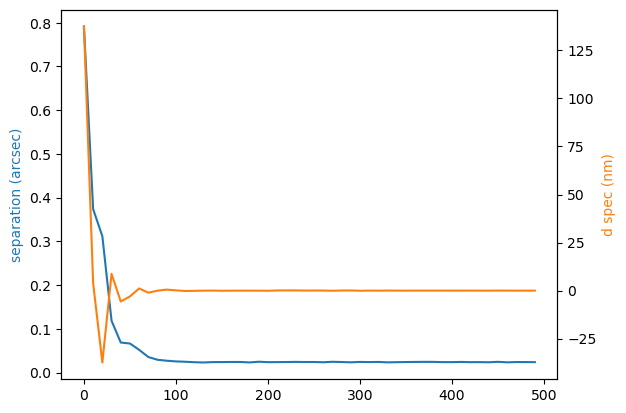

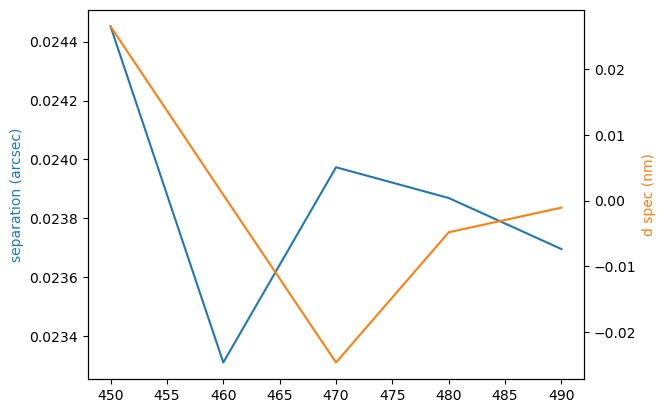

In [15]:
is_ = []
seps = []
dspecs = []
for eval in evals:
    i, sep, dspec = eval
    is_.append(i)
    seps.append(sep.arcsec)
    dspecs.append(dspec.to_value(u.nm))


plt.plot(is_, np.mean(seps, axis=1), label='sky', c='C0')
plt.ylabel('separation (arcsec)', color='C0')
plt.twinx()
plt.plot(is_, np.mean(dspecs, axis=1), label='spec', c='C1')
plt.ylabel('d spec (nm)', color='C1')

plt.figure()
end = slice(int(len(is_)*9/10), None)
plt.plot(is_[end], np.mean(seps[end], axis=1), label='sky', c='C0')
plt.ylabel('separation (arcsec)', color='C0')
plt.twinx()
plt.plot(is_[end], np.mean(dspecs[end], axis=1), label='spec', c='C1')
plt.ylabel('d spec (nm)', color='C1')

np.mean(seps[end], axis=1).std(), np.mean(dspecs[end], axis=1).std()

0.002889871597290039

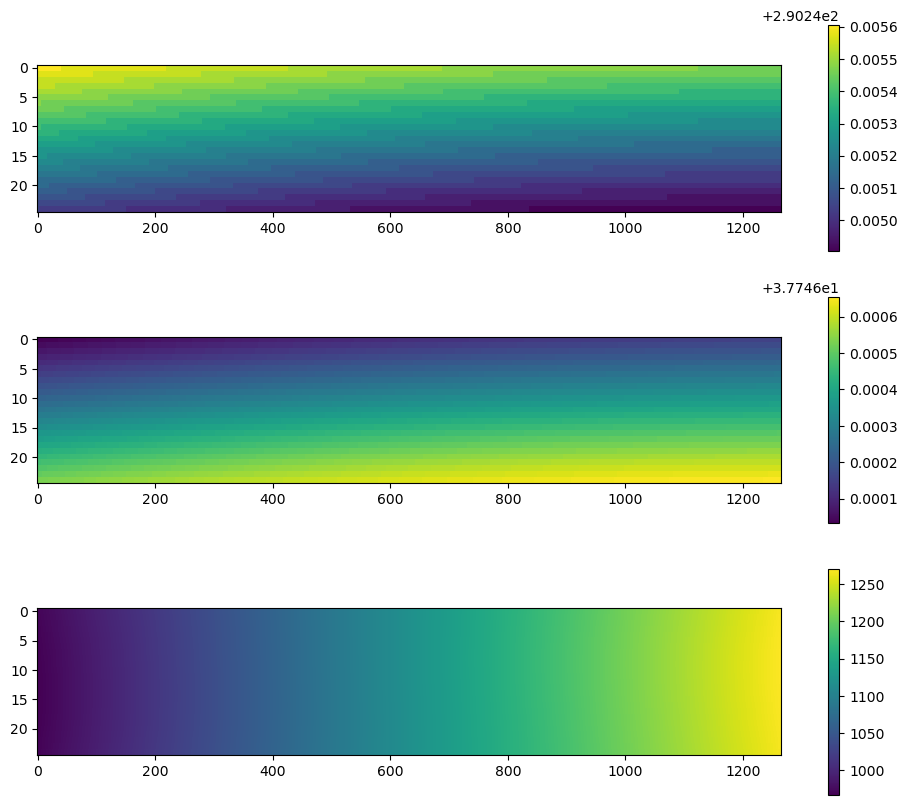

In [37]:
yg, xg = jnp.indices(s.data.shape)

for _ in range(2): # first time might need compiling
    st = time.time()
    sky,spec = infer_pix_to_world(model, xg.ravel(), yg.ravel())
    et = time.time()


sky = sky.reshape(xg.shape)
spec = spec.reshape(xg.shape)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

sc = ax1.imshow(sky.ra.deg, aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax1)
sc = ax2.imshow(sky.dec.deg, aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax2)
sc = ax3.imshow(spec.to_value(u.nm), aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax3)
et-st

Method works, but not enormously faster (probably would be at scale? but this is our problem size)

In [33]:
k1, k2, k3 = jax.random.split(jax.random.PRNGKey(0), 3)

A = jax.random.normal(k1, (10, 10))
O = jax.random.normal(k2, (10,))

@jax.jit
def jax_test(x, y):
    B = A - O
    m = A @ x + B @y
    return m 

# only count the second time to get past any compiling overhead
runcount = 0
while runcount < 2:
    for n in [100, 1000, 25*1300]:
        x, y = jax.random.normal(k3, (2, 10, n)) 
        res = jax_test(x, y)
        res.block_until_ready()

        st = time.time()
        res = jax_test(x, y)
        res.block_until_ready()
        et = time.time()
        if runcount > 0:
            print(n, et - st)
    runcount += 1



100 9.226799011230469e-05
1000 6.961822509765625e-05
32500 4.458427429199219e-05


Something on the scale of a matrix multiply should be tens of microseconds

# Try a polynomial-like solution

$w_k = \Sigma_i \Sigma_j A_{ij}x^i y^j $ 

$ = \Sigma_i \Sigma_j A_{ij} e^{i \ln{x} + j \ln{x}}$

$ = \Sigma_i \Sigma_j e^{i \ln{x} + j \ln{x} + b_{ij}}$ where $A_{ij} = e^{b_{ij}}$ / $b_{ij} = \ln{A_{ij}}$

which is equivalent to a linear layer that takes as its two inputs $\ln{x}$ and $\ln{y}$, the weight matrix is the polynomial coefficients, and the bias is the linear coefficient. Then element wise exponentiate and sum along the relevant axes.

In [260]:
@jax.jit
def logpoly_transform(x, y, ws, bs):
    """
    x is (n,)
    y is (n),
    ws is (ndeg^2, 2)
    bs is (3, ndeg^2)

    any batching should be done by vmap
    """
    lx = jnp.log(x)
    ly = jnp.log(y)

    lxy = jnp.stack([lx, ly], axis=0)

    logpolys = ws @ lxy 
    logpolys = logpolys + bs[..., None]

    polys = jnp.exp(logpolys)

    return jnp.sum(polys, axis=-2)
batched_logpoly_transform = jax.jit(jax.vmap(logpoly_transform, in_axes=(0, 0, None, None)))

x = jnp.array([1., 2., 3.,4.])
y = jnp.array([1., 2., 3.,4.])
ws = jnp.ones((5, 2))
bs = jnp.ones((3, 5))

logpoly_transform(x, y, ws, bs).shape

(3, 4)

In [288]:
ndeg = 4

xp, yp = np.mgrid[:ndeg,:ndeg].reshape(2, ndeg*ndeg, 1)
A = (xg.ravel()**xp * yg.ravel()**yp).T
B = jnp.array(s.meta.wcs.pixel_to_world_values(xg.ravel(), yg.ravel())).T
msk = ~jnp.isnan(B).any(axis=-1)

coeffs = jnp.linalg.lstsq(A[msk], B[msk])[0]
bs = jnp.log(coeffs).T

Array([[-33.50136 ,       -inf, -27.341633, -24.530533, -27.526363,
        -23.62167 , -20.704504, -17.899715, -21.101084, -16.890455,
        -13.932958, -16.420092, -15.789508, -17.238596, -18.290268,
        -19.231903],
       [-35.54119 ,       -inf, -29.38146 , -26.57036 , -29.566193,
        -25.661497, -22.744331, -19.939543, -23.140915, -18.930285,
        -15.972785, -18.459929, -17.829351, -19.278435, -20.330107,
        -21.27174 ],
       [-39.084515,       -inf, -32.93297 , -30.120283, -33.095478,
        -29.208597, -26.29307 , -23.488901, -26.653864, -22.476093,
        -19.520851, -22.023989, -21.18789 , -22.864073, -23.963617,
        -24.91437 ]], dtype=float32)

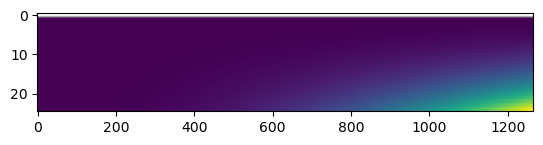

In [301]:
pred = logpoly_transform(xg.ravel(), yg.ravel(), np.mgrid[:ndeg,:ndeg].T.reshape(-1, 2).astype(float), bs.at[jnp.isnan(bs)].set(-jnp.inf))
plt.imshow(pred[0].reshape(xg.shape), aspect=10)


Note it's a bit silly to do this using optax since the model is intrinsically linear.  But if we allow w to vary that's not true and it's easier to keep the flexibility.

  0%|          | 0/200 [00:00<?, ?it/s]

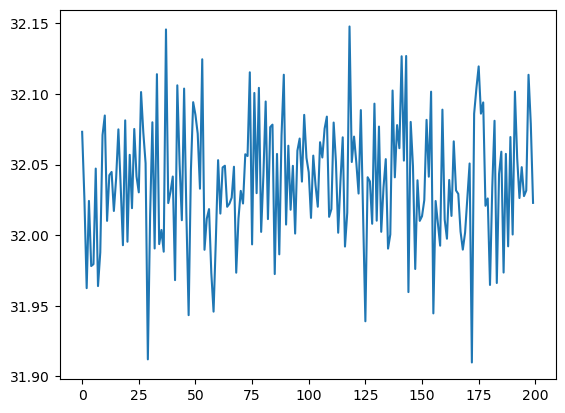

In [201]:
lr = 1e-1
ndeg = 4
iters = 200
data_per_batch = 1024

key = jax.random.PRNGKey(0)

yo = yoff*jnp.array([1,1,1e-3]) # nm->microns
ys = yscale*jnp.array([1,1,1e-3]) # nm->microns

def compute_loss(params, x, y, target):
    pred = logpoly_transform(x, y, params['ws'], params['bs'])
    pred = (pred.T - yo)/ys
    target = (target.T - yo)/ys
    return jnp.mean((pred - target).T**2) 

ws = jnp.repeat(jnp.arange(ndeg), 2).reshape(ndeg, 2).astype(float)
bs = jnp.ones((3, ndeg)).astype(float)
params = {'ws': ws, 'bs': bs}

optimizer = optax.adam(lr)
opt_state = optimizer.init(params)

losses = []
t = tqdm(range(iters))
for _ in t:
  key, subkey = jax.random.split(key)

  x, y = jax.random.uniform(subkey, (2, 2*data_per_batch))
  x = x*s.data.shape[1]
  y = y*s.data.shape[0]
  target = jnp.array(s.meta.wcs.pixel_to_world_values(x, y))

  msk = jnp.isfinite(target).all(axis=0)

  loss, grads = jax.value_and_grad(compute_loss)(params, x[msk][:data_per_batch], y[msk][:data_per_batch], target[:, msk][:, :data_per_batch])
  losses.append(loss)
  t.set_description(f'loss: {loss:.4}')
  updates, opt_state = optimizer.update(grads, opt_state)
  params = optax.apply_updates(params, updates)

plt.plot(np.log10(losses))

(array([1679.,  144.,   80.,   48.,   46.,   24.,   12.,    6.,    6.,
           3.]),
 array([-8.24197125e+05,  2.26581988e+16,  4.53163975e+16,  6.79745963e+16,
         9.06327950e+16,  1.13290998e+17,  1.35949193e+17,  1.58607387e+17,
         1.81265590e+17,  2.03923793e+17,  2.26581996e+17]),
 <BarContainer object of 10 artists>)

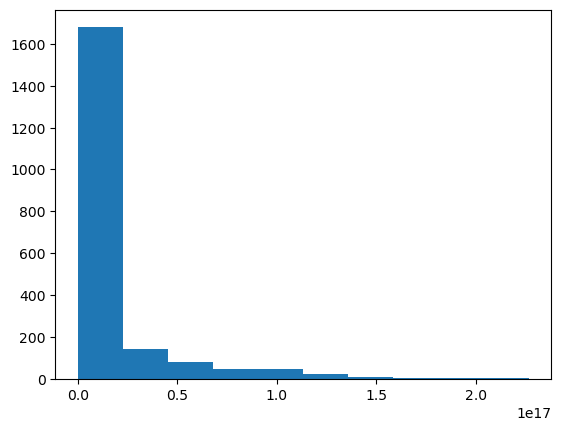

In [216]:
pred = logpoly_transform(x, y, params['ws'], params['bs'])

a,b,c=((pred.T - yo)/ys).T

plt.hist(a)

9.751319885253906e-05

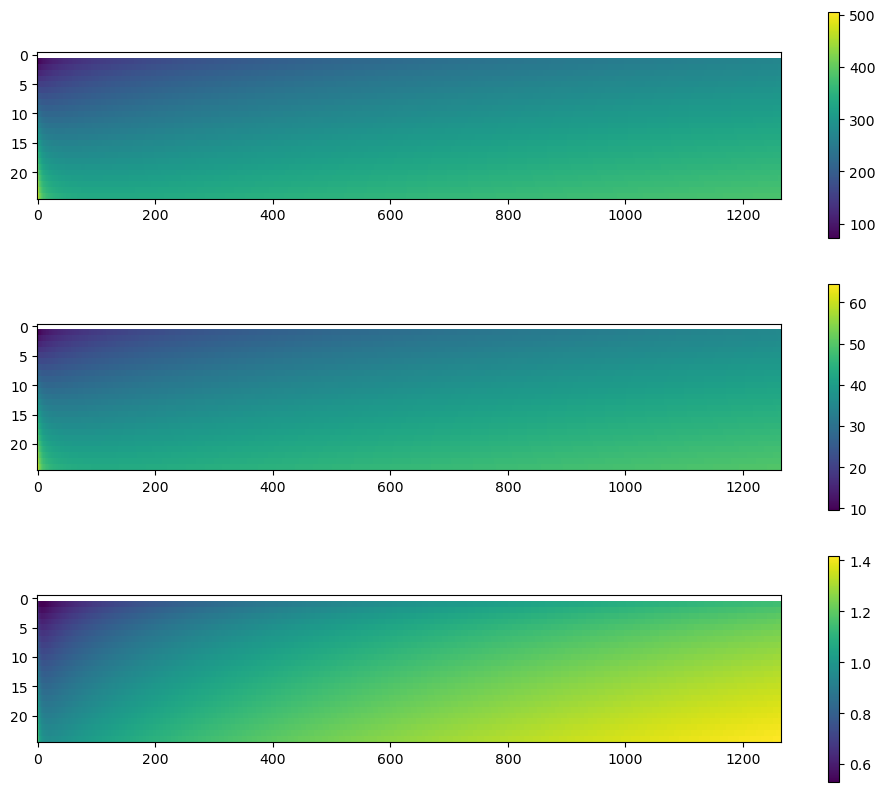

In [155]:
yg, xg = jnp.indices(s.data.shape)

for _ in range(2): # first time might need compiling
    st = time.time()
    ra, dec, spec = logpoly_transform(xg.ravel(), yg.ravel(), params['ws'], params['bs'])
    et = time.time()


sky = sky.reshape(xg.shape)
spec = spec.reshape(xg.shape)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

sc = ax1.imshow(ra.reshape(xg.shape), aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax1)
sc = ax2.imshow(dec.reshape(xg.shape), aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax2)
sc = ax3.imshow(spec.reshape(xg.shape), aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax3)
et-st

(array([28., 19., 25., 22., 21., 17., 29., 28., 28., 22., 35., 25., 21.,
        26., 28., 15., 18., 21., 18., 27., 27., 26., 21., 12., 27., 23.,
        26., 29., 30., 33., 28., 31., 25., 24., 26., 30., 26., 22., 21.,
        24., 27., 21., 32., 26., 16., 29., 22., 28., 32., 19.]),
 array([7.07164232e-04, 2.06990652e-02, 4.06909660e-02, 6.06828667e-02,
        8.06747675e-02, 1.00666672e-01, 1.20658569e-01, 1.40650466e-01,
        1.60642371e-01, 1.80634275e-01, 2.00626180e-01, 2.20618069e-01,
        2.40609974e-01, 2.60601848e-01, 2.80593753e-01, 3.00585657e-01,
        3.20577562e-01, 3.40569466e-01, 3.60561371e-01, 3.80553275e-01,
        4.00545180e-01, 4.20537055e-01, 4.40528959e-01, 4.60520864e-01,
        4.80512768e-01, 5.00504673e-01, 5.20496547e-01, 5.40488482e-01,
        5.60480356e-01, 5.80472291e-01, 6.00464165e-01, 6.20456100e-01,
        6.40447974e-01, 6.60439849e-01, 6.80431783e-01, 7.00423658e-01,
        7.20415592e-01, 7.40407467e-01, 7.60399401e-01, 7.80391276e-

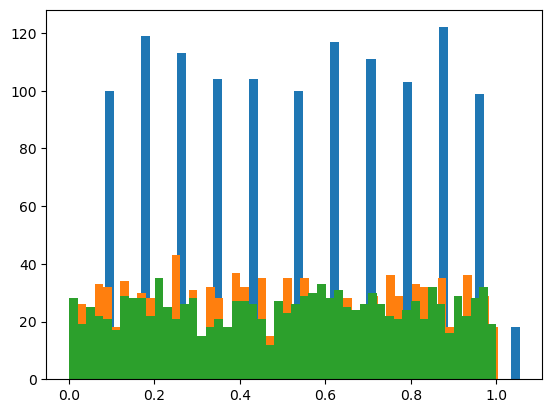

In [193]:
yo2 = yoff*jnp.array([1,1,1e-3])
ys2 = yscale*jnp.array([1,1,1e-3])

a,b,c = ((target.T- yo2)/ys2).T
plt.hist(a[np.isfinite(a)], bins=50)
plt.hist(b[np.isfinite(b)], bins=50)
plt.hist(c[np.isfinite(c)], bins=50)

Blarg ... somethings not right. Try re-working this in [jax_wcs_experimentation_part2.ipynb](jax_wcs_experimentation_part2.ipynb)